In [1]:
# compile results
import pickle

homedir = "/mnt/mirabelle/az6922_homedir/"
cm_list = ["unv1","prv1"]
nfaillinks_list_dict = dict()
nfaillinks_list_dict["leafspine_before"] = [40,81,122,163,204]
nfaillinks_list_dict["dringsu2_before"] = [42,85,127,170,213]
nfaillinks_list_dict["dringsu2_after"] = [42,85,127,170,213]
fseed_list = range(10)
scheme_list = ["dringsu2_before","leafspine_before","dringsu2_after"]
failpct_list = [0,2,4,6,8,10]
load_dict = dict()
load_dict["unv1"] = 2 #4
load_dict["prv1"] = 2 #3
seed = 1

unv1 dringsu2_before means: [1.0, 1.0845167658486763, 1.1311838509245895, 1.1923573747482412, 1.273948128664647, 1.3341676794072281]
unv1 leafspine_before means: [1.0, 1.3259744373292994, 1.9553707195940273, 2.5714380721251016, 3.1686822904279195, 3.9251921596387547]
unv1 dringsu2_after means: [1.0, 1.0744730420824609, 1.091786626499379, 1.123942898549071, 1.1860778127086102, 1.2398181060895663]
prv1 dringsu2_before means: [1.0, 1.0724089461386697, 1.166827709731939, 1.259023068998256, 1.250225572516514, 1.3711391748759354]
prv1 leafspine_before means: [1.0, 1.368619170257174, 2.1031511023772618, 2.777949199917001, 3.6365670275482422, 4.185037451126381]
prv1 dringsu2_after means: [1.0, 1.0505198268141753, 1.0985543158419242, 1.1535605106692433, 1.1717492306967159, 1.2317671754954178]


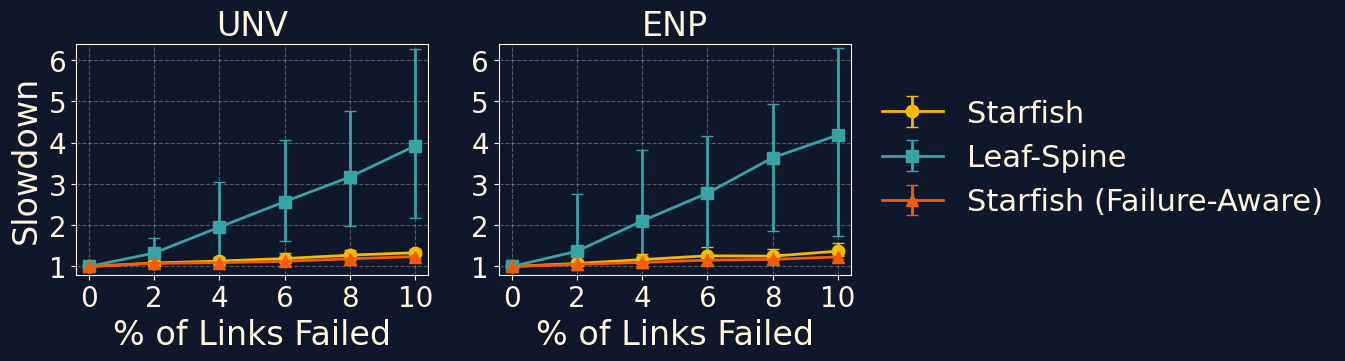

In [ ]:
# plot from txt instead of pickle -- pickle files are too large
import matplotlib.pyplot as plt
import numpy as np

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2_after":"Starfish (Failure-Aware)","dringsu2_before":"Starfish","leafspine_before":"Leaf-Spine"}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2_after":"#f35b04","leafspine_before":"#38a3a5","dringsu2_before":"#f7b801"}

bg_color = "#0F172A"
text_color = "#FFF5E1"

plotdatadict = dict()
sumfile = "fct_summary.txt"

with open(sumfile, "r") as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split("/")
        cm = outfiletokens[0]

        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()

        plotdatadict[cm][outfile] = p99


plotevalmaindatadict = dict()
sumfile = "../eval_main/fct_summary.txt"

with open(sumfile, "r") as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split("/")
        cm = outfiletokens[0]

        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotevalmaindatadict:
            plotevalmaindatadict[cm] = dict()

        plotevalmaindatadict[cm][outfile] = p99


nr = 1
nc = len(cm_list)

fig, axs = plt.subplots(nr, nc, figsize=(nc * 5, nr * 3))
fig.patch.set_facecolor(bg_color)

if nc == 1:
    axs = [axs]

for ic, cm in enumerate(cm_list):
    ax = axs[ic]
    ax.set_facecolor(bg_color)

    for isc, scheme in enumerate(scheme_list):
        fct_list = []

        load = load_dict[cm]

        if "dring" in scheme:
            myscheme = "dringsu2"
        else:
            myscheme = "leafspine"

        outfile = f"{cm}/outfiles/{myscheme}_load{load}_seed{seed}.out"
        p99_baseline = plotevalmaindatadict[cm][outfile]

        fct_list.append([1])

        for nfaillinks in nfaillinks_list_dict[scheme]:
            fct_list_allseeds = []

            for fseed in fseed_list:
                outfile = f"{cm}/outfiles/{scheme}_nfaillinks{nfaillinks}_fseed{fseed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99 / p99_baseline)

            fct_list.append(fct_list_allseeds)

        means = [sum(x) / len(x) for x in fct_list]
        yerr_lower = [sum(x) / len(x) - min(x) for x in fct_list]
        yerr_upper = [max(x) - sum(x) / len(x) for x in fct_list]

        print(f"{cm} {scheme} means: {means}")

        label = plotlabeldict[scheme] if ic == 0 else None

        ax.errorbar(
            failpct_list,
            means,
            yerr=[yerr_lower, yerr_upper],
            marker=plotmarkers[isc],
            label=label,
            alpha=1,
            capsize=4,
            color=plotcolordict[scheme],
            linewidth=2,
            markersize=9,
        )

    ax.set_xlabel("% of Links Failed", fontsize=24, color=text_color)
    ax.set_title(plottitledict[cm], fontsize=24, color=text_color)

    ax.tick_params(axis="both", labelsize=20, colors=text_color)

    ax.grid(True, linestyle="--", alpha=0.3, color=text_color)

    ax.set_xticks([0, 2, 4, 6, 8, 10])
    ax.set_yticks([1, 2, 3, 4, 5, 6])
    ax.set_xlim(-0.4, 10.4)
    ax.set_ylim(0.8, 6.4)

    for spine in ax.spines.values():
        spine.set_color(text_color)

axs[0].set_ylabel("Slowdown", fontsize=24, color=text_color)

legend = fig.legend(
    loc="center right",
    bbox_to_anchor=(1.4, 0.5),
    ncol=1,
    fontsize=22,
    frameon=False,
)

for text in legend.get_texts():
    text.set_color(text_color)

plt.savefig(f"talk_failure_link_full.pdf", dpi=600, bbox_inches='tight', facecolor=fig.get_facecolor())

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


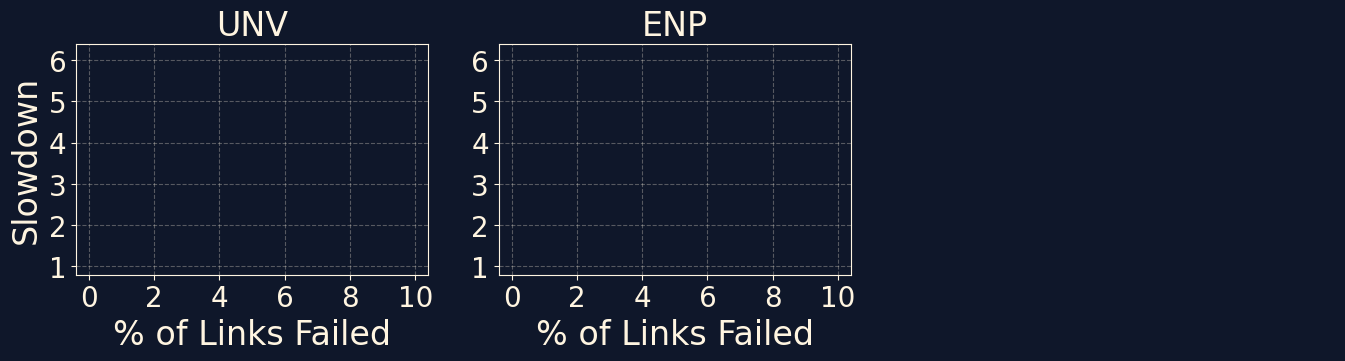

In [20]:
# plot from txt instead of pickle -- pickle files are too large
import matplotlib.pyplot as plt
import numpy as np

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2_after":"Starfish (Failure-Aware)","dringsu2_before":"Starfish","leafspine_before":"Leaf-Spine"}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2_after":"#f35b04","leafspine_before":"#38a3a5","dringsu2_before":"#f7b801"}

bg_color = "#0F172A"
text_color = "#FFF5E1"

plotdatadict = dict()
sumfile = "fct_summary.txt"

with open(sumfile, "r") as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split("/")
        cm = outfiletokens[0]

        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()

        plotdatadict[cm][outfile] = p99


plotevalmaindatadict = dict()
sumfile = "../eval_main/fct_summary.txt"

with open(sumfile, "r") as f:
    for line in f:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split("/")
        cm = outfiletokens[0]

        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotevalmaindatadict:
            plotevalmaindatadict[cm] = dict()

        plotevalmaindatadict[cm][outfile] = p99


nr = 1
nc = len(cm_list)

fig, axs = plt.subplots(nr, nc, figsize=(nc * 5, nr * 3))
fig.patch.set_facecolor(bg_color)

if nc == 1:
    axs = [axs]

for ic, cm in enumerate(cm_list):
    ax = axs[ic]
    ax.set_facecolor(bg_color)

    for isc, scheme in enumerate(scheme_list):
        fct_list = []

        load = load_dict[cm]

        if "dring" in scheme:
            myscheme = "dringsu2"
        else:
            myscheme = "leafspine"

        outfile = f"{cm}/outfiles/{myscheme}_load{load}_seed{seed}.out"
        p99_baseline = plotevalmaindatadict[cm][outfile]

        fct_list.append([1])

        for nfaillinks in nfaillinks_list_dict[scheme]:
            fct_list_allseeds = []

            for fseed in fseed_list:
                outfile = f"{cm}/outfiles/{scheme}_nfaillinks{nfaillinks}_fseed{fseed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99 / p99_baseline)

            fct_list.append(fct_list_allseeds)

        means = [sum(x) / len(x) for x in fct_list]
        yerr_lower = [sum(x) / len(x) - min(x) for x in fct_list]
        yerr_upper = [max(x) - sum(x) / len(x) for x in fct_list]

        label = plotlabeldict[scheme] if ic == 0 else None

        # ax.errorbar(
        #     failpct_list,
        #     means,
        #     yerr=[yerr_lower, yerr_upper],
        #     marker=plotmarkers[isc],
        #     label=label,
        #     alpha=1,
        #     capsize=4,
        #     color=plotcolordict[scheme],
        #     linewidth=2,
        #     markersize=9,
        # )

    ax.set_xlabel("% of Links Failed", fontsize=24, color=text_color)
    ax.set_title(plottitledict[cm], fontsize=24, color=text_color)

    ax.tick_params(axis="both", labelsize=20, colors=text_color)

    ax.grid(True, linestyle="--", alpha=0.3, color=text_color)

    ax.set_xticks([0, 2, 4, 6, 8, 10])
    ax.set_yticks([1, 2, 3, 4, 5, 6])
    ax.set_xlim(-0.4, 10.4)
    ax.set_ylim(0.8, 6.4)

    for spine in ax.spines.values():
        spine.set_color(text_color)

axs[0].set_ylabel("Slowdown", fontsize=24, color=text_color)

legend = fig.legend(
    loc="center right",
    bbox_to_anchor=(1.4, 0.5),
    ncol=1,
    fontsize=22,
    frameon=False,
)

for text in legend.get_texts():
    text.set_color(text_color)

plt.savefig(f"talk_failure_link_empty.pdf", dpi=600, bbox_inches='tight', facecolor=fig.get_facecolor())